In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:

#load ID datasets extracted features
medSAM_ZGT= torch.load("medSAM_LoRA_ZGT_allmasses")
VersaMammo_ZGT= torch.load("VersaMammo_ZGT_allmasses")

#load OOD datasets extracted features
medSAM_INBreast= torch.load("medSAM_LoRA_INBreast_masses")
VersaMammo_INBreast= torch.load("VersaMammo_INBreast_masses")

print(medSAM_ZGT.shape)
print(VersaMammo_ZGT.shape)
print(medSAM_INBreast.shape)
print(VersaMammo_INBreast.shape)

torch.Size([159, 256])
torch.Size([159, 768])
torch.Size([108, 256])
torch.Size([108, 768])


In [4]:
def pytorchood_mahalanobis_cov(z, y, eps=1e-6):
    device = z.device
    classes = y.unique()
    n_classes = len(classes)

    mu = torch.zeros((n_classes, z.shape[-1]), device=device)
    cov = torch.zeros((z.shape[-1], z.shape[-1]), device=device)

    for clazz in range(n_classes):
        idx = y.eq(clazz)
        zs = z[idx]

        mu[clazz] = zs.mean(dim=0)
        centered = zs - mu[clazz]

        cov += centered.T @ centered

    cov += torch.eye(cov.shape[0], device=device) * eps
    precision = torch.linalg.inv(cov)

    return mu, cov, precision

In [6]:
y_id=torch.zeros(medSAM_ZGT.shape[0])

_,cov_medSAM, prec_medSAM=pytorchood_mahalanobis_cov(medSAM_ZGT, y_id)
_, cov_VersaMammo, prec_VersaMammo=pytorchood_mahalanobis_cov(VersaMammo_ZGT, y_id)

eigvals_medSAM = torch.linalg.eigvalsh(cov_medSAM)
eigvals_VersaMammo = torch.linalg.eigvalsh(cov_VersaMammo)

In [3]:
# cov_medSAM=torch.cov(medSAM_ZGT.T)
# cov_VersaMammo=torch.cov(VersaMammo_ZGT.T)

# eigvals_medSAM = torch.linalg.eigvalsh(cov_medSAM)
# eigvals_VersaMammo = torch.linalg.eigvalsh(cov_VersaMammo)


In [7]:
print((eigvals_VersaMammo < 1e-10).sum())

tensor(228)


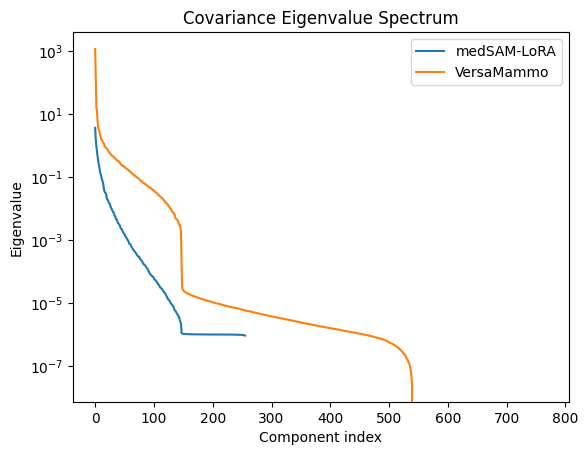

In [8]:


# Sort eigenvalues first
eigvals_medSAM = torch.sort(eigvals_medSAM, descending=True).values
eigvals_VersaMammo = torch.sort(eigvals_VersaMammo, descending=True).values

# Plot both
plt.plot(eigvals_medSAM.cpu().numpy(), label="medSAM-LoRA")
plt.plot(eigvals_VersaMammo.cpu().numpy(), label="VersaMammo")

plt.title("Covariance Eigenvalue Spectrum")
plt.xlabel("Component index")
plt.ylabel("Eigenvalue")
plt.yscale("log")  # very useful!
plt.legend()       # <-- this is key

plt.show()

In [9]:
def proj(cov_matrix, z_id, z_ood, eps=1e-8):
    
    eigvals, eigvecs = torch.linalg.eigh(cov_matrix)

    # Center using ID mean
    mu_id = z_id.mean(dim=0)

    Z_id_centered = z_id - mu_id
    Z_ood_centered = z_ood - mu_id

    # Project onto covariance eigenvectors
    proj_id = Z_id_centered @ eigvecs
    proj_ood = Z_ood_centered @ eigvecs

    # Variance along each eigen-direction
    var_id = proj_id.var(dim=0)
    var_ood = proj_ood.var(dim=0)

    # Mahalanobis contribution per sample, per eigen-direction
    mahal_contrib_id = (proj_id ** 2) / (eigvals + eps)
    mahal_contrib_ood = (proj_ood ** 2) / (eigvals + eps)

    # Mean contribution per eigen-direction
    mean_mahal_contrib_id = mahal_contrib_id.mean(dim=0)
    mean_mahal_contrib_ood = mahal_contrib_ood.mean(dim=0)

    return {
        "var_id": var_id,
        "var_ood": var_ood,
        "eigvals": eigvals,
        "mahal_contrib_id": mahal_contrib_id,
        "mahal_contrib_ood": mahal_contrib_ood,
        "mean_mahal_contrib_id": mean_mahal_contrib_id,
        "mean_mahal_contrib_ood": mean_mahal_contrib_ood,
    }

In [10]:
out_medSAM = proj(cov_medSAM, medSAM_ZGT, medSAM_INBreast)

eigvals_MedSAM = out_medSAM["eigvals"]
id_contrib_MedSAM = out_medSAM["mean_mahal_contrib_id"]
ood_contrib_MedSAM = out_medSAM["mean_mahal_contrib_ood"]

# Sort by eigenvalue, descending
idx = torch.argsort(eigvals_MedSAM, descending=True)

eigvals_sorted = eigvals_MedSAM[idx]
id_contrib_sorted = id_contrib_MedSAM[idx]
ood_contrib_sorted = ood_contrib_MedSAM[idx]

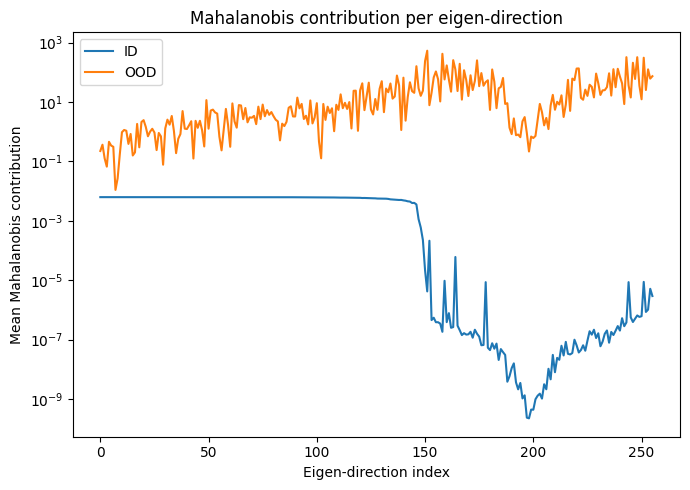

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(id_contrib_sorted.detach().cpu().numpy(), label="ID")
plt.plot(ood_contrib_sorted.detach().cpu().numpy(), label="OOD")
plt.yscale("log")
plt.xlabel("Eigen-direction index")
plt.ylabel("Mean Mahalanobis contribution")
plt.title("Mahalanobis contribution per eigen-direction")
plt.legend()
plt.tight_layout()
plt.show()

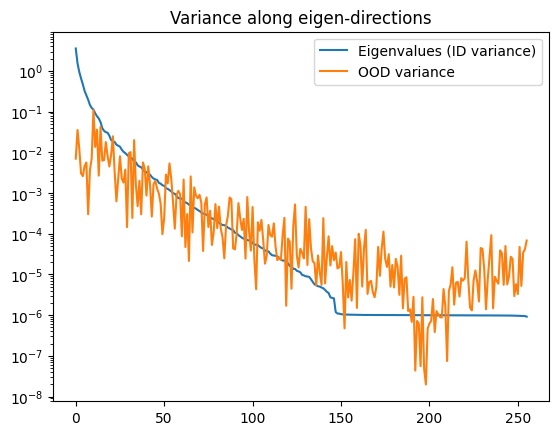

In [12]:
var_id_medSAM= out_medSAM["var_id"]
var_ood_medSAM= out_medSAM["var_ood"]


var_id_sorted = var_id_medSAM[idx]
var_ood_sorted = var_ood_medSAM[idx]

plt.plot(eigvals_sorted.cpu(), label="Eigenvalues (ID variance)")
plt.plot(var_ood_sorted.cpu(), label="OOD variance")
plt.yscale("log")
plt.legend()
plt.title("Variance along eigen-directions")
plt.show()

tensor(0.8929) tensor(0.1649)
tensor(7981.4175) tensor(2107.9932)


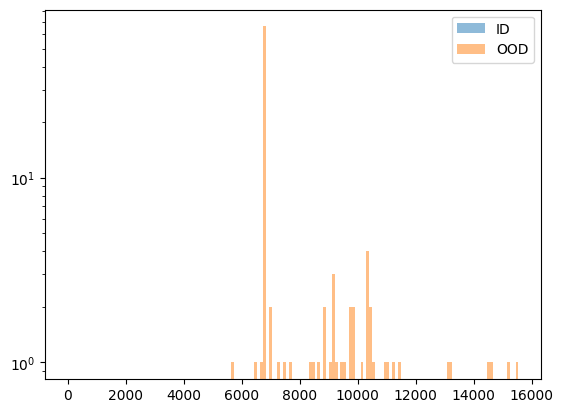

In [13]:
id_scores = out_medSAM["mahal_contrib_id"].sum(dim=1)
ood_scores = out_medSAM["mahal_contrib_ood"].sum(dim=1)

print(id_scores.mean(), id_scores.std())
print(ood_scores.mean(), ood_scores.std())


plt.hist(id_scores.detach().cpu().numpy(), bins=100, alpha=0.5, label="ID")
plt.hist(ood_scores.detach().cpu().numpy(), bins=100, alpha=0.5, label="OOD")
plt.yscale("log")
plt.legend()
plt.show()

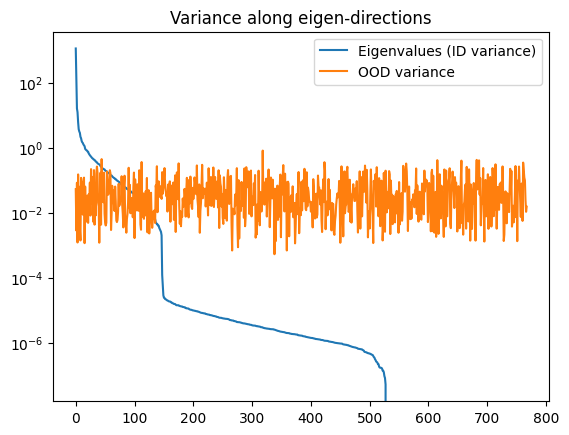

In [14]:
out_VersaMammo=proj(cov_VersaMammo, VersaMammo_ZGT, VersaMammo_INBreast)

var_id_VersaMammo = out_VersaMammo["var_id"]
var_ood_VersaMammo= out_VersaMammo["var_ood"]
eigvals_VersaMammo= out_VersaMammo["eigvals"]


idx = torch.argsort(eigvals_VersaMammo, descending=True)

eigvals_sorted = eigvals_VersaMammo[idx]
var_id_sorted = var_id_VersaMammo[idx]
var_ood_sorted = var_ood_VersaMammo[idx]

plt.plot(eigvals_sorted.cpu(), label="Eigenvalues (ID variance)")
plt.plot(var_ood_sorted.cpu(), label="OOD variance")
plt.yscale("log")
plt.legend()
plt.title("Variance along eigen-directions")
plt.show()

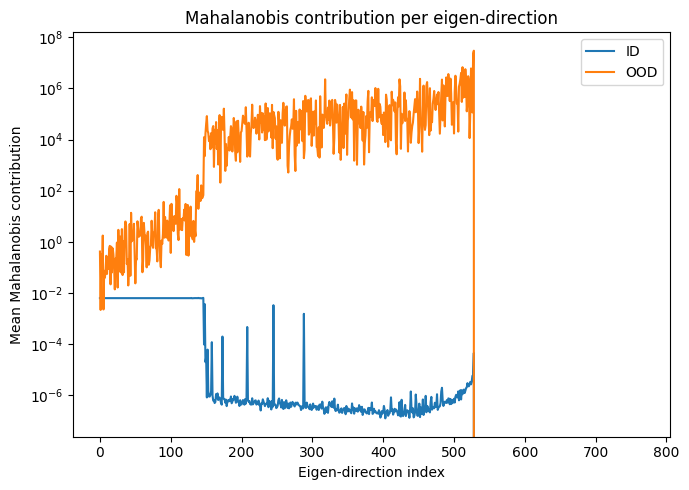

In [15]:

id_contrib = out_VersaMammo["mean_mahal_contrib_id"]
ood_contrib = out_VersaMammo["mean_mahal_contrib_ood"]

# Sort by eigenvalue, descending
idx = torch.argsort(eigvals_VersaMammo, descending=True)

eigvals_sorted = eigvals_VersaMammo[idx]
id_contrib_sorted = id_contrib[idx]
ood_contrib_sorted = ood_contrib[idx]


plt.figure(figsize=(7, 5))
plt.plot(id_contrib_sorted.detach().cpu().numpy(), label="ID")
plt.plot(ood_contrib_sorted.detach().cpu().numpy(), label="OOD")
plt.yscale("log")
plt.xlabel("Eigen-direction index")
plt.ylabel("Mean Mahalanobis contribution")
plt.title("Mahalanobis contribution per eigen-direction")
plt.legend()
plt.tight_layout()
plt.show()

tensor(0.9250) tensor(0.1738)
tensor(47019292.) tensor(35768156.)


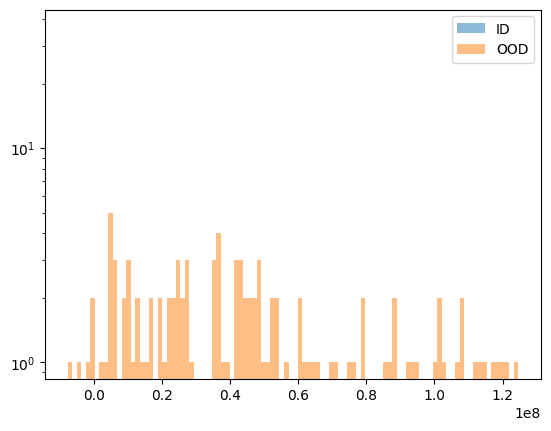

In [16]:
id_scores = out_VersaMammo["mahal_contrib_id"].sum(dim=1)
ood_scores = out_VersaMammo["mahal_contrib_ood"].sum(dim=1)

print(id_scores.mean(), id_scores.std())
print(ood_scores.mean(), ood_scores.std())


plt.hist(id_scores.detach().cpu().numpy(), bins=100, alpha=0.5, label="ID")
plt.hist(ood_scores.detach().cpu().numpy(), bins=100, alpha=0.5, label="OOD")
plt.yscale("log")
plt.legend()
plt.show()